dict_keys(['CMI_C01', 'DQF_C01', 'CMI_C02', 'DQF_C02', 'CMI_C03', 'DQF_C03', 'CMI_C04', 'DQF_C04', 'CMI_C05', 'DQF_C05', 'CMI_C06', 'DQF_C06', 'CMI_C07', 'DQF_C07', 'CMI_C08', 'DQF_C08', 'CMI_C09', 'DQF_C09', 'CMI_C10', 'DQF_C10', 'CMI_C11', 'DQF_C11', 'CMI_C12', 'DQF_C12', 'CMI_C13', 'DQF_C13', 'CMI_C14', 'DQF_C14', 'CMI_C15', 'DQF_C15', 'CMI_C16', 'DQF_C16', 't', 'y', 'x', 'time_bounds', 'goes_imager_projection', 'y_image', 'y_image_bounds', 'x_image', 'x_image_bounds', 'nominal_satellite_subpoint_lat', 'nominal_satellite_subpoint_lon', 'nominal_satellite_height', 'geospatial_lat_lon_extent', 'band_wavelength_C01', 'band_wavelength_C02', 'band_wavelength_C03', 'band_wavelength_C04', 'band_wavelength_C05', 'band_wavelength_C06', 'band_wavelength_C07', 'band_wavelength_C08', 'band_wavelength_C09', 'band_wavelength_C10', 'band_wavelength_C11', 'band_wavelength_C12', 'band_wavelength_C13', 'band_wavelength_C14', 'band_wavelength_C15', 'band_wavelength_C16', 'band_id_C01', 'band_id_C02', 

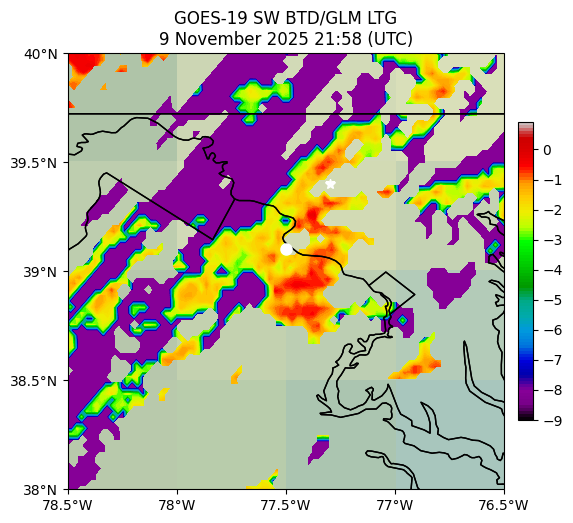

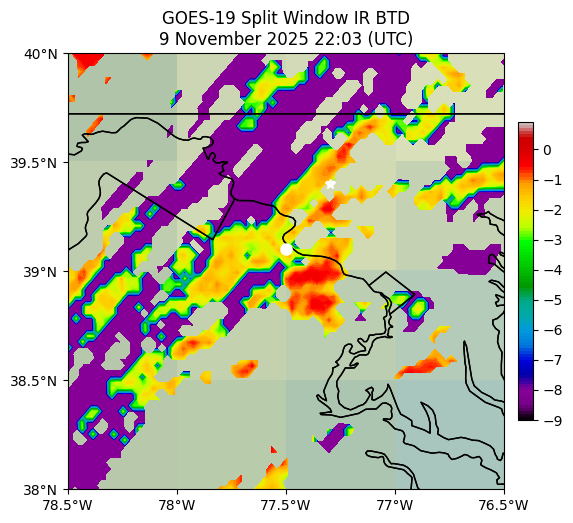

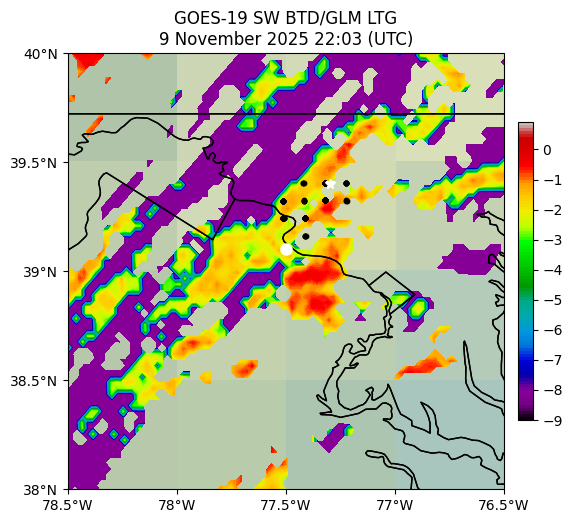

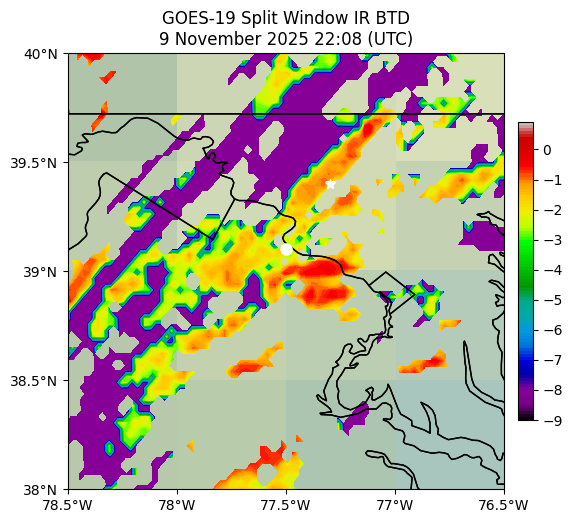

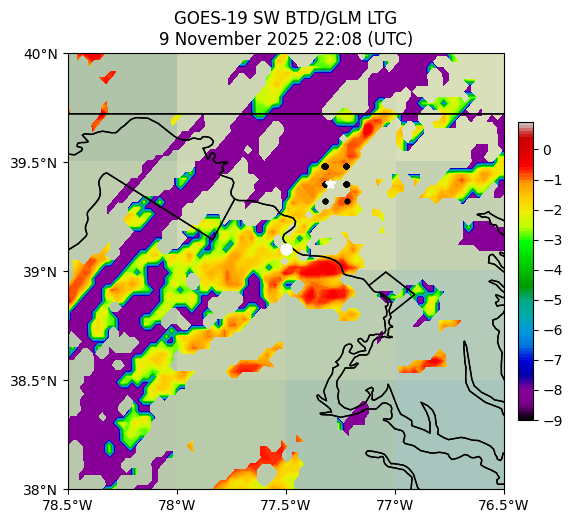

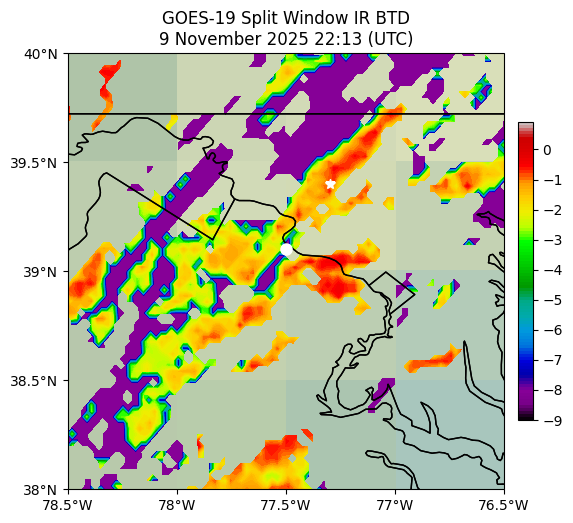

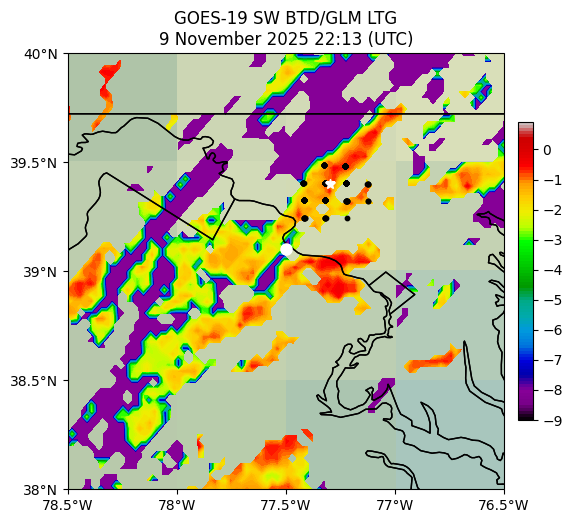

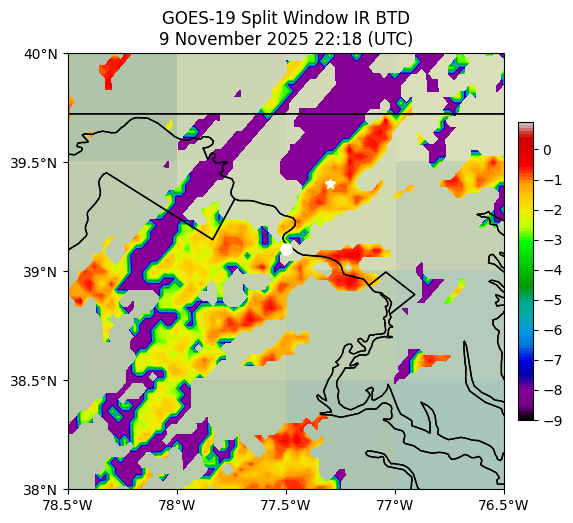

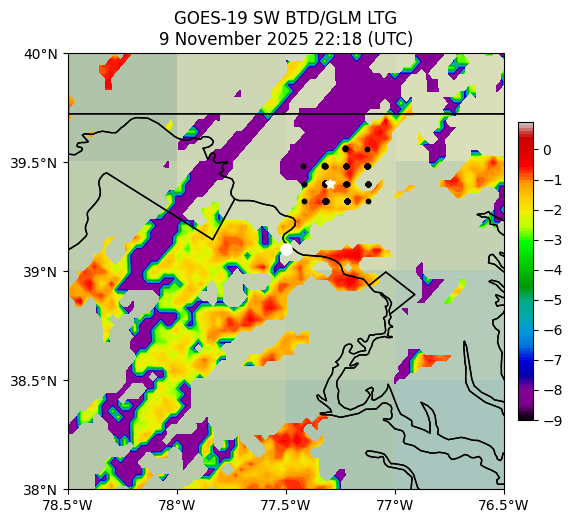

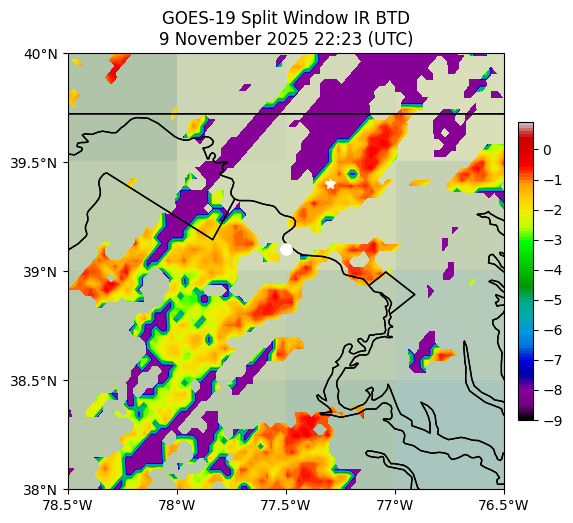

In [22]:
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import cartopy.crs as crs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from datetime import datetime
import xarray as xr


def read_IR_plot(ncf):
    nc_fid = Dataset(ncf, 'r')
    IR1 = nc_fid.variables["CMI_C13"][:]  # shape lat, lon as shown above
    IR2 = nc_fid.variables["CMI_C15"][:]  # shape lat, lon as shown above
    WV = nc_fid.variables["CMI_C10"][:]  # shape lat, lon as shown above
    X = nc_fid.variables["x"][:]
    Y = nc_fid.variables["y"][:]
    names = nc_fid.variables.keys()
    nc_fid.close()
    return IR1, IR2, WV, X, Y, names

def convert_lat_lon(x,y):
    r_eq = 6378137
    r_pol = 6356752.31414
    H = 42164160
    L_0 = -1.308996939    #longitude_of_projection_origin -75 deg
    a = ((np.sin(x))**2) + (((np.cos(x))**2) * (((np.cos(y))**2) + (((r_eq/r_pol)**2) * ((np.sin(y))**2))))
    b = -2 * H * (np.cos(x)) * (np.cos(y))
    c = (H**2) - (r_eq**2)
    r_s = ((-b ) - ((((b)**2) - (4 * a * c))**0.5))/(2*a)
    S_x = r_s * np.cos(x) * np.cos(y)
    S_y = -r_s * np.sin(x)
    S_z = r_s * np.cos(x) * np.sin(y)

    lat_rad = np.arctan(((r_eq/r_pol)**2)*((S_z)/(((H - S_x)**2)+(S_y)**2)**0.5))
    lon_rad = L_0 - np.arctan(S_y/(H - S_x))
    lat = (180 / (np.pi)) * lat_rad
    lon = (180 / (np.pi)) * lon_rad
    return lat,lon

IR_file = 'OR_ABI-L2-MCMIPC-M6_G19_s20253132156182_e20253132158555_c20253132159240.nc'
IR1, IR2, WV, X, Y, names = read_IR_plot(IR_file)
IR1 = IR1[100:1000,1000:2000]
IR2 = IR2[100:1000,1000:2000]
WV = WV[100:1000,1000:2000]
X = X[1000:2000]
Y = Y[100:1000]
print(names)
print('IR1 shape', IR1.shape, IR1)
print('IR2 shape', IR2.shape, IR2)
print('WV shape', WV.shape, WV)
print('X shape, Y shape', X.shape, Y.shape, X, Y)

BTD_IR = np.subtract(IR2,IR1)
print('BTD_IR shape', BTD_IR.shape)

BTD_ma = ma.masked_where(IR1 > 270, BTD_IR)
print('BTD_ma shape', BTD_ma.shape)

BTD_ma[BTD_ma<-3.0]=-8.01
print('BTD_ma shape', BTD_ma.shape, BTD_ma)

lats = np.zeros((900,1000))
lons = np.zeros((900,1000))
for i in range(0,900):
    for j in range(0,1000):
        lat, lon = convert_lat_lon(X[j],Y[i])
        lats[i,j] = lat
        lons[i,j] = lon

print("lats shape", lats.shape, lats)
print("Lons shape", lons.shape, lons)
np.delete(X,[0])
np.delete(Y,[0])

file_path = 'OR_GLM-L2-LCFA_G19_s20253132158000_e20253132158200_c20253132158215.nc'
g19_ds_2158 = xr.open_dataset(file_path)
event_lat_2158 = g19_ds_2158.variables['event_lat'][:]
event_lon_2158 = g19_ds_2158.variables['event_lon'][:]
file_path = 'OR_GLM-L2-LCFA_G19_s20253132158200_e20253132158400_c20253132158416.nc'
g19_ds_215820 = xr.open_dataset(file_path)
event_lat_215820 = g19_ds_215820.variables['event_lat'][:]
event_lon_215820 = g19_ds_215820.variables['event_lon'][:]
file_path = 'OR_GLM-L2-LCFA_G19_s20253132158400_e20253132159000_c20253132159017.nc'
g19_ds_215840 = xr.open_dataset(file_path)
event_lat_215840 = g19_ds_215840.variables['event_lat'][:]
event_lon_215840 = g19_ds_215840.variables['event_lon'][:]

# CREATE A MAP
fig = plt.figure(figsize=(6, 6))
img_extent = (-78.5, -76.5, 38, 40)
ax = plt.axes(projection=crs.PlateCarree(globe=None))
ax.set_extent([-78.5, -76.5, 38, 40], crs.PlateCarree(globe=None))
ax.stock_img()

plt.title('GOES-19 SW BTD/GLM LTG\n'
          '9 November 2025 21:58 (UTC)')

Tlevels = np.arange(-9,1,0.1)
cbtd = ax.contourf(lons,lats,BTD_ma,Tlevels,extent=img_extent, transform=crs.PlateCarree(),cmap='nipy_spectral')
ax.scatter(event_lon_2158, event_lat_2158, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.scatter(event_lon_215820, event_lat_215820, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.scatter(event_lon_215840, event_lat_215840, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.set_xticks([-78.5,-78,-77.5,-77,-76.5])
ax.set_yticks([38,38.5,39,39.5,40])
ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=crs.Geodetic())
ax.plot(-77.5, 39.1, 'ow', markersize=8, transform=crs.Geodetic())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()

ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
cbar=plt.colorbar(cbtd,fraction=0.032,pad=0.03)

plt.savefig("SW_IR_ma_GLM_G19_2158.png",dpi=250,bbox_inches='tight')

IR_file = 'OR_ABI-L2-MCMIPC-M6_G19_s20253132201182_e20253132203555_c20253132204252.nc'
IR1, IR2, WV, X, Y, names = read_IR_plot(IR_file)
IR1 = IR1[100:1000,1000:2000]
IR2 = IR2[100:1000,1000:2000]
WV = WV[100:1000,1000:2000]
X = X[1000:2000]
Y = Y[100:1000]
print(names)
print('IR1 shape', IR1.shape, IR1)
print('IR2 shape', IR2.shape, IR2)
print('WV shape', WV.shape, WV)
print('X shape, Y shape', X.shape, Y.shape, X, Y)

BTD_IR = np.subtract(IR2,IR1)
print('BTD_IR shape', BTD_IR.shape)

BTD_ma = ma.masked_where(IR1 > 270, BTD_IR)
print('BTD_ma shape', BTD_ma.shape)

BTD_ma[BTD_ma<-3.0]=-8.01
print('BTD_ma shape', BTD_ma.shape, BTD_ma)

lats = np.zeros((900,1000))
lons = np.zeros((900,1000))
for i in range(0,900):
    for j in range(0,1000):
        lat, lon = convert_lat_lon(X[j],Y[i])
        lats[i,j] = lat
        lons[i,j] = lon

print("lats shape", lats.shape, lats)
print("Lons shape", lons.shape, lons)
np.delete(X,[0])
np.delete(Y,[0])

file_path = 'OR_GLM-L2-LCFA_G19_s20253132203000_e20253132203200_c20253132203219.nc'
g19_ds_2203 = xr.open_dataset(file_path)
event_lat_2203 = g19_ds_2203.variables['event_lat'][:]
event_lon_2203 = g19_ds_2203.variables['event_lon'][:]
file_path = 'OR_GLM-L2-LCFA_G19_s20253132203200_e20253132203400_c20253132203416.nc'
g19_ds_220320 = xr.open_dataset(file_path)
event_lat_220320 = g19_ds_220320.variables['event_lat'][:]
event_lon_220320 = g19_ds_220320.variables['event_lon'][:]
file_path = 'OR_GLM-L2-LCFA_G19_s20253132203400_e20253132204000_c20253132204018.nc'
g19_ds_220340 = xr.open_dataset(file_path)
event_lat_220340 = g19_ds_220340.variables['event_lat'][:]
event_lon_220340 = g19_ds_220340.variables['event_lon'][:]

# CREATE A MAP
fig = plt.figure(figsize=(6, 6))
img_extent = (-78.5, -76.5, 38, 40)
ax = plt.axes(projection=crs.PlateCarree(globe=None))
ax.set_extent([-78.5, -76.5, 38, 40], crs.PlateCarree(globe=None))
ax.stock_img()

plt.title('GOES-19 Split Window IR BTD\n'
          '9 November 2025 22:03 (UTC)')

Tlevels = np.arange(-9,1,0.1)
cbtd = ax.contourf(lons,lats,BTD_ma,Tlevels,extent=img_extent, transform=crs.PlateCarree(),cmap='nipy_spectral')
ax.set_xticks([-78.5,-78,-77.5,-77,-76.5])
ax.set_yticks([38,38.5,39,39.5,40])
ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=crs.Geodetic())
ax.plot(-77.5, 39.1, 'ow', markersize=8, transform=crs.Geodetic())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()

ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
cbar=plt.colorbar(cbtd,fraction=0.032,pad=0.03)
plt.savefig("SW_IR_ma_G19_2203.png",dpi=250,bbox_inches='tight')

# CREATE A MAP
fig = plt.figure(figsize=(6, 6))
img_extent = (-78.5, -76.5, 38, 40)
ax = plt.axes(projection=crs.PlateCarree(globe=None))
ax.set_extent([-78.5, -76.5, 38, 40], crs.PlateCarree(globe=None))
ax.stock_img()

plt.title('GOES-19 SW BTD/GLM LTG\n'
          '9 November 2025 22:03 (UTC)')

Tlevels = np.arange(-9,1,0.1)
cbtd = ax.contourf(lons,lats,BTD_ma,Tlevels,extent=img_extent, transform=crs.PlateCarree(),cmap='nipy_spectral')
ax.scatter(event_lon_2203, event_lat_2203, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.scatter(event_lon_220320, event_lat_220320, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.scatter(event_lon_220340, event_lat_220340, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.set_xticks([-78.5,-78,-77.5,-77,-76.5])
ax.set_yticks([38,38.5,39,39.5,40])
ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=crs.Geodetic())
ax.plot(-77.5, 39.1, 'ow', markersize=8, transform=crs.Geodetic())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()

ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
cbar=plt.colorbar(cbtd,fraction=0.032,pad=0.03)

plt.savefig("SW_IR_ma_GLM_G19_2203.png",dpi=250,bbox_inches='tight')

IR_file = 'OR_ABI-L2-MCMIPC-M6_G19_s20253132206182_e20253132208555_c20253132209238.nc'
IR1, IR2, WV, X, Y, names = read_IR_plot(IR_file)
IR1 = IR1[100:1000,1000:2000]
IR2 = IR2[100:1000,1000:2000]
WV = WV[100:1000,1000:2000]
X = X[1000:2000]
Y = Y[100:1000]
print(names)
print('IR1 shape', IR1.shape, IR1)
print('IR2 shape', IR2.shape, IR2)
print('WV shape', WV.shape, WV)
print('X shape, Y shape', X.shape, Y.shape, X, Y)

BTD_IR = np.subtract(IR2,IR1)
print('BTD_IR shape', BTD_IR.shape)

BTD_ma = ma.masked_where(IR1 > 270, BTD_IR)
print('BTD_ma shape', BTD_ma.shape)

BTD_ma[BTD_ma<-3.0]=-8.01
print('BTD_ma shape', BTD_ma.shape, BTD_ma)

lats = np.zeros((900,1000))
lons = np.zeros((900,1000))
for i in range(0,900):
    for j in range(0,1000):
        lat, lon = convert_lat_lon(X[j],Y[i])
        lats[i,j] = lat
        lons[i,j] = lon

print("lats shape", lats.shape, lats)
print("Lons shape", lons.shape, lons)
np.delete(X,[0])
np.delete(Y,[0])

file_path = 'OR_GLM-L2-LCFA_G19_s20253132208000_e20253132208200_c20253132208221.nc'
g19_ds_2208 = xr.open_dataset(file_path)
event_lat_2208 = g19_ds_2208.variables['event_lat'][:]
event_lon_2208 = g19_ds_2208.variables['event_lon'][:]
file_path = 'OR_GLM-L2-LCFA_G19_s20253132208200_e20253132208400_c20253132208417.nc'
g19_ds_220820 = xr.open_dataset(file_path)
event_lat_220820 = g19_ds_220820.variables['event_lat'][:]
event_lon_220820 = g19_ds_220820.variables['event_lon'][:]
file_path = 'OR_GLM-L2-LCFA_G19_s20253132208400_e20253132209000_c20253132209018.nc'
g19_ds_220840 = xr.open_dataset(file_path)
event_lat_220840 = g19_ds_220840.variables['event_lat'][:]
event_lon_220840 = g19_ds_220840.variables['event_lon'][:]

# CREATE A MAP
fig = plt.figure(figsize=(6, 6))
img_extent = (-78.5, -76.5, 38, 40)
ax = plt.axes(projection=crs.PlateCarree(globe=None))
ax.set_extent([-78.5, -76.5, 38, 40], crs.PlateCarree(globe=None))
ax.stock_img()

plt.title('GOES-19 Split Window IR BTD\n'
          '9 November 2025 22:08 (UTC)')

Tlevels = np.arange(-9,1,0.1)
cbtd = ax.contourf(lons,lats,BTD_ma,Tlevels,extent=img_extent, transform=crs.PlateCarree(),cmap='nipy_spectral')

ax.set_xticks([-78.5,-78,-77.5,-77,-76.5])
ax.set_yticks([38,38.5,39,39.5,40])
ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=crs.Geodetic())
ax.plot(-77.5, 39.1, 'ow', markersize=8, transform=crs.Geodetic())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()

ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
cbar=plt.colorbar(cbtd,fraction=0.032,pad=0.03)

plt.savefig("SW_IR_ma_G19_2208.png",dpi=250,bbox_inches='tight')

# CREATE A MAP
fig = plt.figure(figsize=(6, 6))
img_extent = (-78.5, -76.5, 38, 40)
ax = plt.axes(projection=crs.PlateCarree(globe=None))
ax.set_extent([-78.5, -76.5, 38, 40], crs.PlateCarree(globe=None))
ax.stock_img()

plt.title('GOES-19 SW BTD/GLM LTG\n'
          '9 November 2025 22:08 (UTC)')

Tlevels = np.arange(-9,1,0.1)
cbtd = ax.contourf(lons,lats,BTD_ma,Tlevels,extent=img_extent, transform=crs.PlateCarree(),cmap='nipy_spectral')
ax.scatter(event_lon_2208, event_lat_2208, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.scatter(event_lon_220820, event_lat_220820, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.scatter(event_lon_220840, event_lat_220840, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.set_xticks([-78.5,-78,-77.5,-77,-76.5])
ax.set_yticks([38,38.5,39,39.5,40])
ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=crs.Geodetic())
ax.plot(-77.5, 39.1, 'ow', markersize=8, transform=crs.Geodetic())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()

ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
cbar=plt.colorbar(cbtd,fraction=0.032,pad=0.03)

plt.savefig("SW_IR_ma_GLM_G19_2208.png",dpi=250,bbox_inches='tight')

IR_file = 'OR_ABI-L2-MCMIPC-M6_G19_s20253132211182_e20253132213555_c20253132214265.nc'
IR1, IR2, WV, X, Y, names = read_IR_plot(IR_file)
IR1 = IR1[100:1000,1000:2000]
IR2 = IR2[100:1000,1000:2000]
WV = WV[100:1000,1000:2000]
X = X[1000:2000]
Y = Y[100:1000]
print(names)
print('IR1 shape', IR1.shape, IR1)
print('IR2 shape', IR2.shape, IR2)
print('WV shape', WV.shape, WV)
print('X shape, Y shape', X.shape, Y.shape, X, Y)

BTD_IR = np.subtract(IR2,IR1)
print('BTD_IR shape', BTD_IR.shape)

BTD_ma = ma.masked_where(IR1 > 270, BTD_IR)
print('BTD_ma shape', BTD_ma.shape)

BTD_ma[BTD_ma<-3.0]=-8.01
print('BTD_ma shape', BTD_ma.shape, BTD_ma)

lats = np.zeros((900,1000))
lons = np.zeros((900,1000))
for i in range(0,900):
    for j in range(0,1000):
        lat, lon = convert_lat_lon(X[j],Y[i])
        lats[i,j] = lat
        lons[i,j] = lon

print("lats shape", lats.shape, lats)
print("Lons shape", lons.shape, lons)
np.delete(X,[0])
np.delete(Y,[0])

file_path = 'OR_GLM-L2-LCFA_G19_s20253132213000_e20253132213200_c20253132213216.nc'
g19_ds_2213 = xr.open_dataset(file_path)
event_lat_2213 = g19_ds_2213.variables['event_lat'][:]
event_lon_2213 = g19_ds_2213.variables['event_lon'][:]
file_path = 'OR_GLM-L2-LCFA_G19_s20253132213200_e20253132213400_c20253132213416.nc'
g19_ds_221320 = xr.open_dataset(file_path)
event_lat_221320 = g19_ds_221320.variables['event_lat'][:]
event_lon_221320 = g19_ds_221320.variables['event_lon'][:]
file_path = 'OR_GLM-L2-LCFA_G19_s20253132213400_e20253132214000_c20253132214018.nc'
g19_ds_221340 = xr.open_dataset(file_path)
event_lat_221340 = g19_ds_221340.variables['event_lat'][:]
event_lon_221340 = g19_ds_221340.variables['event_lon'][:]

# CREATE A MAP
fig = plt.figure(figsize=(6, 6))
img_extent = (-78.5, -76.5, 38, 40)
ax = plt.axes(projection=crs.PlateCarree(globe=None))
ax.set_extent([-78.5, -76.5, 38, 40], crs.PlateCarree(globe=None))
ax.stock_img()

plt.title('GOES-19 Split Window IR BTD\n'
          '9 November 2025 22:13 (UTC)')

Tlevels = np.arange(-9,1,0.1)
cbtd = ax.contourf(lons,lats,BTD_ma,Tlevels,extent=img_extent, transform=crs.PlateCarree(),cmap='nipy_spectral')

ax.set_xticks([-78.5,-78,-77.5,-77,-76.5])
ax.set_yticks([38,38.5,39,39.5,40])
ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=crs.Geodetic())
ax.plot(-77.5, 39.1, 'ow', markersize=8, transform=crs.Geodetic())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()

ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
cbar=plt.colorbar(cbtd,fraction=0.032,pad=0.03)

plt.savefig("SW_IR_ma_G19_2213.png",dpi=250,bbox_inches='tight')

# CREATE A MAP
fig = plt.figure(figsize=(6, 6))
img_extent = (-78.5, -76.5, 38, 40)
ax = plt.axes(projection=crs.PlateCarree(globe=None))
ax.set_extent([-78.5, -76.5, 38, 40], crs.PlateCarree(globe=None))
ax.stock_img()

plt.title('GOES-19 SW BTD/GLM LTG\n'
          '9 November 2025 22:13 (UTC)')

Tlevels = np.arange(-9,1,0.1)
cbtd = ax.contourf(lons,lats,BTD_ma,Tlevels,extent=img_extent, transform=crs.PlateCarree(),cmap='nipy_spectral')
ax.scatter(event_lon_2213, event_lat_2213, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.scatter(event_lon_221320, event_lat_221320, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.scatter(event_lon_221340, event_lat_221340, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.set_xticks([-78.5,-78,-77.5,-77,-76.5])
ax.set_yticks([38,38.5,39,39.5,40])
ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=crs.Geodetic())
ax.plot(-77.5, 39.1, 'ow', markersize=8, transform=crs.Geodetic())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()

ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
cbar=plt.colorbar(cbtd,fraction=0.032,pad=0.03)

plt.savefig("SW_IR_ma_GLM_G19_2213.png",dpi=250,bbox_inches='tight')

IR_file = 'OR_ABI-L2-MCMIPC-M6_G19_s20253132216182_e20253132218555_c20253132219243.nc'
IR1, IR2, WV, X, Y, names = read_IR_plot(IR_file)
IR1 = IR1[100:1000,1000:2000]
IR2 = IR2[100:1000,1000:2000]
WV = WV[100:1000,1000:2000]
X = X[1000:2000]
Y = Y[100:1000]
print(names)
print('IR1 shape', IR1.shape, IR1)
print('IR2 shape', IR2.shape, IR2)
print('WV shape', WV.shape, WV)
print('X shape, Y shape', X.shape, Y.shape, X, Y)

BTD_IR = np.subtract(IR2,IR1)
print('BTD_IR shape', BTD_IR.shape)

BTD_ma = ma.masked_where(IR1 > 270, BTD_IR)
print('BTD_ma shape', BTD_ma.shape)

BTD_ma[BTD_ma<-3.0]=-8.01
print('BTD_ma shape', BTD_ma.shape, BTD_ma)

lats = np.zeros((900,1000))
lons = np.zeros((900,1000))
for i in range(0,900):
    for j in range(0,1000):
        lat, lon = convert_lat_lon(X[j],Y[i])
        lats[i,j] = lat
        lons[i,j] = lon

print("lats shape", lats.shape, lats)
print("Lons shape", lons.shape, lons)
np.delete(X,[0])
np.delete(Y,[0])

file_path = 'OR_GLM-L2-LCFA_G19_s20253132217200_e20253132217400_c20253132217417.nc'
g19_ds_221720 = xr.open_dataset(file_path)
event_lat_221720 = g19_ds_221720.variables['event_lat'][:]
event_lon_221720 = g19_ds_221720.variables['event_lon'][:]
file_path = 'OR_GLM-L2-LCFA_G19_s20253132217400_e20253132218000_c20253132218017.nc'
g19_ds_221740 = xr.open_dataset(file_path)
event_lat_221740 = g19_ds_221740.variables['event_lat'][:]
event_lon_221740 = g19_ds_221740.variables['event_lon'][:]
file_path = 'OR_GLM-L2-LCFA_G19_s20253132218000_e20253132218200_c20253132218215.nc'
g19_ds_2218 = xr.open_dataset(file_path)
event_lat_2218 = g19_ds_2218.variables['event_lat'][:]
event_lon_2218 = g19_ds_2218.variables['event_lon'][:]

# CREATE A MAP
fig = plt.figure(figsize=(6, 6))
img_extent = (-78.5, -76.5, 38, 40)
ax = plt.axes(projection=crs.PlateCarree(globe=None))
ax.set_extent([-78.5, -76.5, 38, 40], crs.PlateCarree(globe=None))
ax.stock_img()

plt.title('GOES-19 Split Window IR BTD\n'
          '9 November 2025 22:18 (UTC)')

Tlevels = np.arange(-9,1,0.1)
cbtd = ax.contourf(lons,lats,BTD_ma,Tlevels,extent=img_extent, transform=crs.PlateCarree(),cmap='nipy_spectral')

ax.set_xticks([-78.5,-78,-77.5,-77,-76.5])
ax.set_yticks([38,38.5,39,39.5,40])
ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=crs.Geodetic())
ax.plot(-77.5, 39.1, 'ow', markersize=8, transform=crs.Geodetic())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()

ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
cbar=plt.colorbar(cbtd,fraction=0.032,pad=0.03)

plt.savefig("SW_IR_ma_G19_2218.png",dpi=250,bbox_inches='tight')

# CREATE A MAP
fig = plt.figure(figsize=(6, 6))
img_extent = (-78.5, -76.5, 38, 40)
ax = plt.axes(projection=crs.PlateCarree(globe=None))
ax.set_extent([-78.5, -76.5, 38, 40], crs.PlateCarree(globe=None))
ax.stock_img()

plt.title('GOES-19 SW BTD/GLM LTG\n'
          '9 November 2025 22:18 (UTC)')

Tlevels = np.arange(-9,1,0.1)
cbtd = ax.contourf(lons,lats,BTD_ma,Tlevels,extent=img_extent, transform=crs.PlateCarree(),cmap='nipy_spectral')
ax.scatter(event_lon_2218, event_lat_2218, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.scatter(event_lon_221720, event_lat_221720, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.scatter(event_lon_221740, event_lat_221740, color='black', marker='o', s=10, transform=crs.PlateCarree(), label='GLM Events')
ax.set_xticks([-78.5,-78,-77.5,-77,-76.5])
ax.set_yticks([38,38.5,39,39.5,40])
ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=crs.Geodetic())
ax.plot(-77.5, 39.1, 'ow', markersize=8, transform=crs.Geodetic())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()

ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
cbar=plt.colorbar(cbtd,fraction=0.032,pad=0.03)

plt.savefig("SW_IR_ma_GLM_G19_2218.png",dpi=250,bbox_inches='tight')

IR_file = 'OR_ABI-L2-MCMIPC-M6_G19_s20253132221182_e20253132223555_c20253132224243.nc'
IR1, IR2, WV, X, Y, names = read_IR_plot(IR_file)
IR1 = IR1[100:1000,1000:2000]
IR2 = IR2[100:1000,1000:2000]
WV = WV[100:1000,1000:2000]
X = X[1000:2000]
Y = Y[100:1000]
print(names)
print('IR1 shape', IR1.shape, IR1)
print('IR2 shape', IR2.shape, IR2)
print('WV shape', WV.shape, WV)
print('X shape, Y shape', X.shape, Y.shape, X, Y)

BTD_IR = np.subtract(IR2,IR1)
print('BTD_IR shape', BTD_IR.shape)

BTD_ma = ma.masked_where(IR1 > 270, BTD_IR)
print('BTD_ma shape', BTD_ma.shape)

BTD_ma[BTD_ma<-3.0]=-8.01
print('BTD_ma shape', BTD_ma.shape, BTD_ma)

lats = np.zeros((900,1000))
lons = np.zeros((900,1000))
for i in range(0,900):
    for j in range(0,1000):
        lat, lon = convert_lat_lon(X[j],Y[i])
        lats[i,j] = lat
        lons[i,j] = lon

print("lats shape", lats.shape, lats)
print("Lons shape", lons.shape, lons)
np.delete(X,[0])
np.delete(Y,[0])

# CREATE A MAP
fig = plt.figure(figsize=(6, 6))
img_extent = (-78.5, -76.5, 38, 40)
ax = plt.axes(projection=crs.PlateCarree(globe=None))
ax.set_extent([-78.5, -76.5, 38, 40], crs.PlateCarree(globe=None))
ax.stock_img()

plt.title('GOES-19 Split Window IR BTD\n'
          '9 November 2025 22:23 (UTC)')

Tlevels = np.arange(-9,1,0.1)
cbtd = ax.contourf(lons,lats,BTD_ma,Tlevels,extent=img_extent, transform=crs.PlateCarree(),cmap='nipy_spectral')

ax.set_xticks([-78.5,-78,-77.5,-77,-76.5])
ax.set_yticks([38,38.5,39,39.5,40])
ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=crs.Geodetic())
ax.plot(-77.5, 39.1, 'ow', markersize=8, transform=crs.Geodetic())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

lon_formatter = LongitudeFormatter()
lat_formatter = LatitudeFormatter()

ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
cbar=plt.colorbar(cbtd,fraction=0.032,pad=0.03)

plt.savefig("SW_IR_ma_G19_2223.png",dpi=250,bbox_inches='tight')

In [23]:
import glob
from PIL import Image

def make_gif(frame_folder, output_filename, duration=100, loop=0):
    """
    Creates an animated GIF from images in a folder.

    :param frame_folder: Path to the folder containing image frames.
    :param output_filename: The name of the output GIF file.
    :param duration: Duration of each frame in milliseconds (default 100ms).
    :param loop: The number of times the GIF should loop (0 means infinite loop).
    """
    # Use glob to find all JPG files and sort them
    frames = [Image.open(image) for image in sorted(glob.glob(f"{frame_folder}/*.PNG"))]
    
    # Ensure images have the same dimensions for best results
    
    # The first frame is used to save the file and append the rest of the frames
    if frames:
        frame_one = frames[0]
        frame_one.save(
            output_filename, 
            format="GIF", 
            append_images=frames[1:], 
            save_all=True, 
            duration=duration, 
            loop=loop
        )
        print(f"GIF saved as {output_filename}")
    else:
        print("No images found in the specified folder.")

# Example usage (replace '/path/to/images' with your actual folder path)
if __name__ == "__main__":
    make_gif("./SWIR_1109", "SW_IR_ma_G19.gif", duration=1000, loop=0)

# Example usage (replace '/path/to/images' with your actual folder path)
if __name__ == "__main__":
    make_gif("./SWIR_GLM_1109", "SW_IR_GLM_G19.gif", duration=1000, loop=0)


GIF saved as SW_IR_ma_G19.gif
GIF saved as SW_IR_GLM_G19.gif


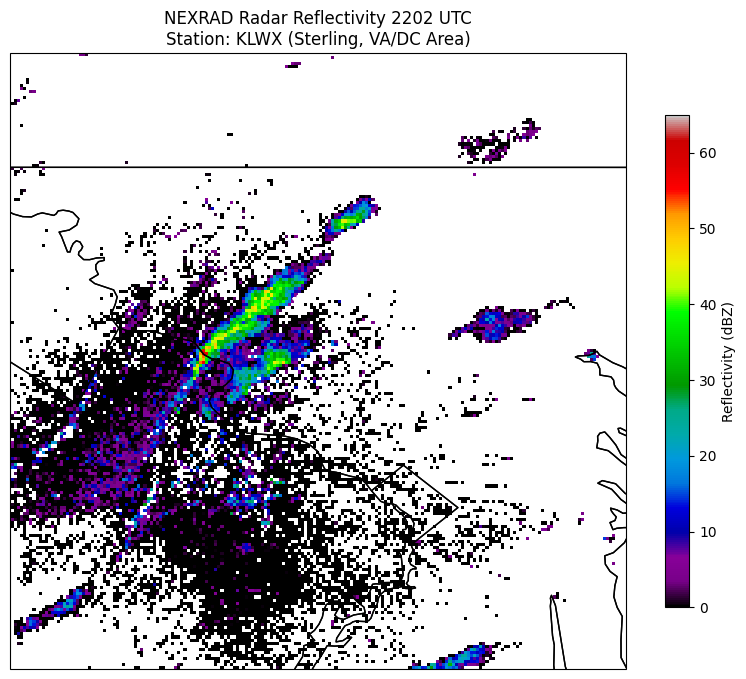

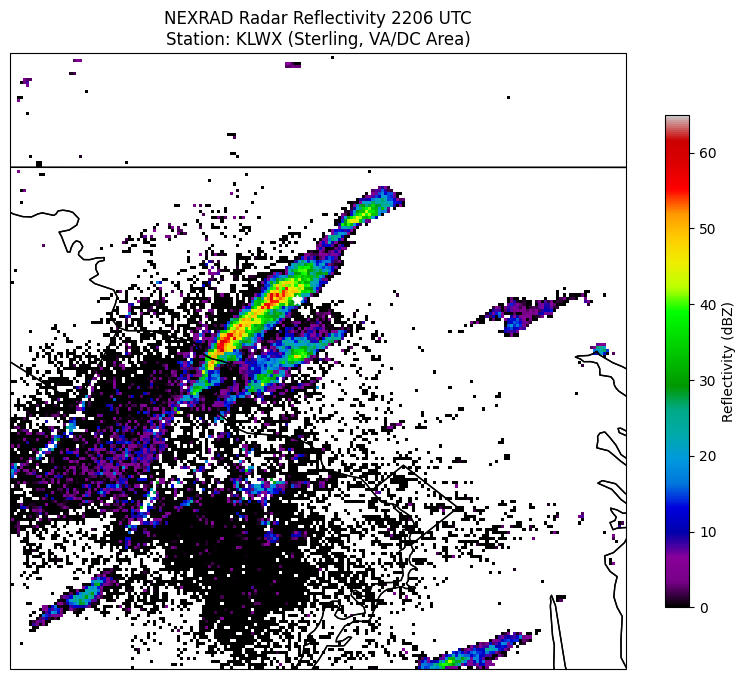

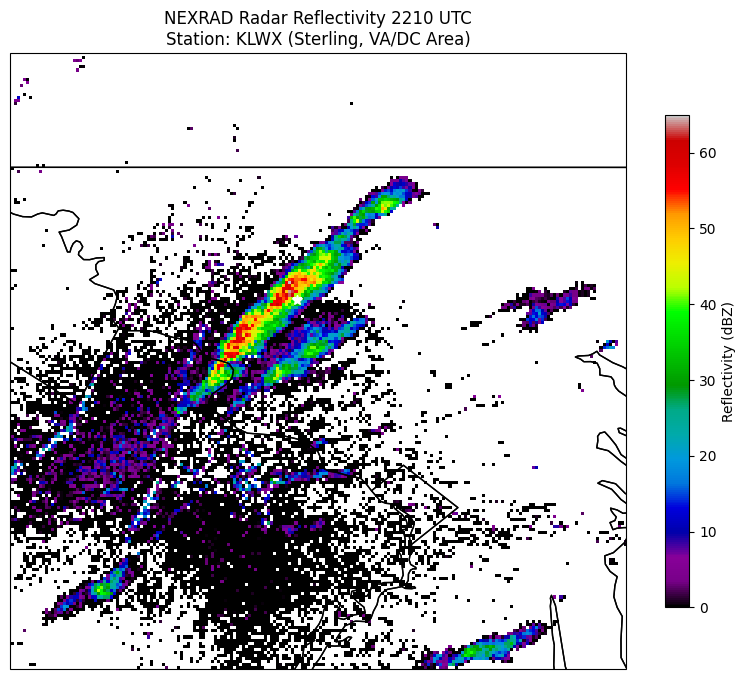

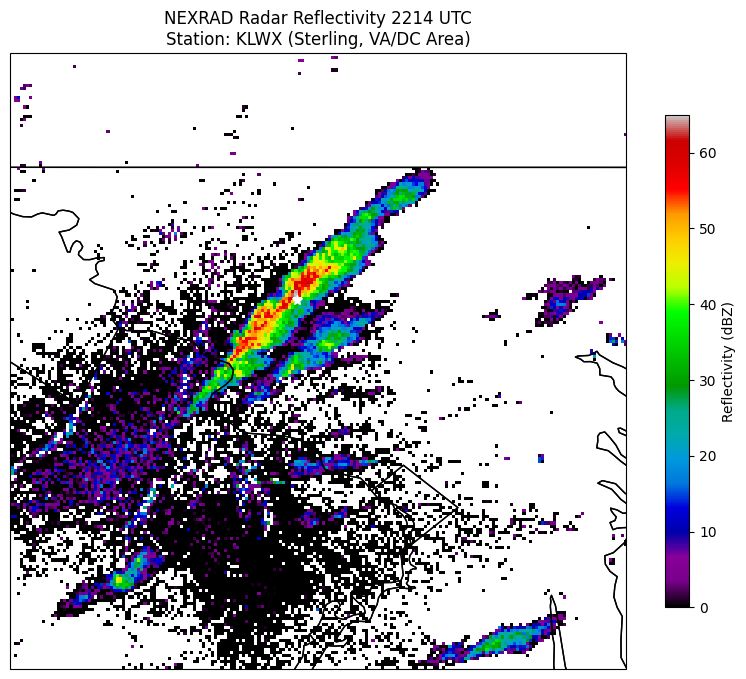

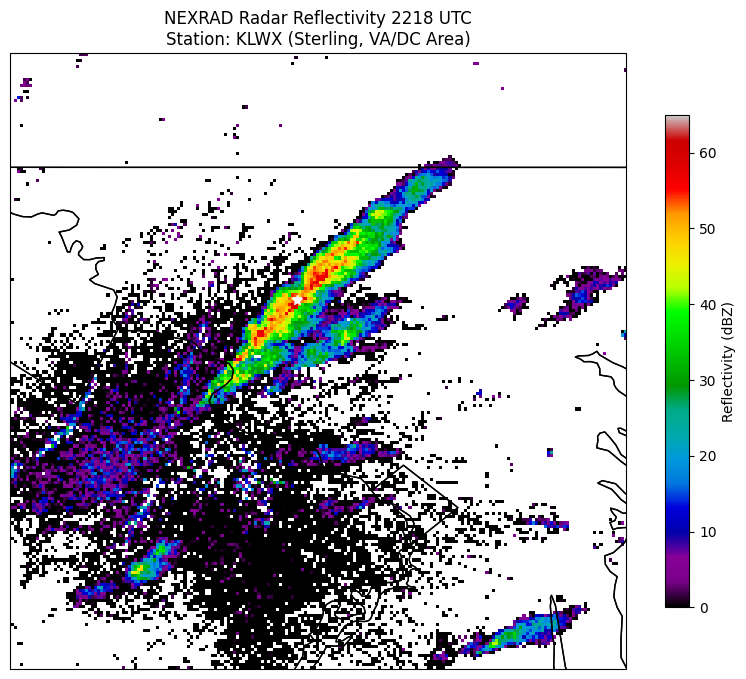

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset
import numpy as np

# Load the file
file_path = 'KLWX_V06_20251109_220203_Z.nc'

try:
    nc = Dataset(file_path, 'r')

    # Read the data variables
    # Based on the file snippet provided
    lats = nc.variables['lat'][:]
    lons = nc.variables['lon'][:]
    ref = nc.variables['Reflectivity'][:]

    # Close the file
    nc.close()

    # Pre-process the data
    # Squeeze to remove single dimensions (e.g., time) if they exist
    ref = np.squeeze(ref)

    # Mask missing or invalid data (often labeled as -999 or similar in radar data)
    # Reflectivity is typically masked below a certain threshold (like 0 or -30 dBZ)
    # Check for the '_FillValue' or 'missing_value' attribute in a real scenario
    # Here we mask values less than -30 dBZ which is typical for "no signal"
    ref_masked = np.ma.masked_less(ref, -30)

    # Set up the plot
    fig = plt.figure(figsize=(10, 8))

    # Define projection
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set extent to cover Central Maryland and surrounding areas
    # Approx Extent: West -78, East -76, South 38, North 40
    extent = [-78, -76.5, 38.5, 40]
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add Map Features
    ax.add_feature(cfeature.STATES, linewidth=1.0)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    # Adding counties can be helpful for radar
    #ax.add_feature(cfeature.COUNTIES, linewidth=0.3, linestyle=':')

    # Plot the Radar Data
    # 'nipy_spectral' is a popular colormap for radar reflectivity
    mesh = ax.pcolormesh(lons, lats, ref_masked,
                         transform=ccrs.PlateCarree(),
                         cmap='nipy_spectral',
                         vmin=0, vmax=65) # Standard dBZ range
    ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=ccrs.Geodetic())
    # Add Colorbar
    cbar = plt.colorbar(mesh, orientation='vertical', label='Reflectivity (dBZ)', shrink=0.8)

    # Title
    plt.title('NEXRAD Radar Reflectivity 2202 UTC\nStation: KLWX (Sterling, VA/DC Area)')
    plt.savefig("KLWX_V06_20251109_2202_Z.png",dpi=250,bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

# Load the file
file_path = 'KLWX_V06_20251109_220626_Z.nc'

try:
    nc = Dataset(file_path, 'r')

    # Read the data variables
    # Based on the file snippet provided
    lats = nc.variables['lat'][:]
    lons = nc.variables['lon'][:]
    ref = nc.variables['Reflectivity'][:]

    # Close the file
    nc.close()

    # Pre-process the data
    # Squeeze to remove single dimensions (e.g., time) if they exist
    ref = np.squeeze(ref)

    # Mask missing or invalid data (often labeled as -999 or similar in radar data)
    # Reflectivity is typically masked below a certain threshold (like 0 or -30 dBZ)
    # Check for the '_FillValue' or 'missing_value' attribute in a real scenario
    # Here we mask values less than -30 dBZ which is typical for "no signal"
    ref_masked = np.ma.masked_less(ref, -30)

    # Set up the plot
    fig = plt.figure(figsize=(10, 8))

    # Define projection
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set extent to cover Central Maryland and surrounding areas
    # Approx Extent: West -78, East -76, South 38, North 40
    extent = [-78, -76.5, 38.5, 40]
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add Map Features
    ax.add_feature(cfeature.STATES, linewidth=1.0)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    # Adding counties can be helpful for radar
    #ax.add_feature(cfeature.COUNTIES, linewidth=0.3, linestyle=':')

    # Plot the Radar Data
    # 'nipy_spectral' is a popular colormap for radar reflectivity
    mesh = ax.pcolormesh(lons, lats, ref_masked,
                         transform=ccrs.PlateCarree(),
                         cmap='nipy_spectral',
                         vmin=0, vmax=65) # Standard dBZ range
    ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=ccrs.Geodetic())
    # Add Colorbar
    cbar = plt.colorbar(mesh, orientation='vertical', label='Reflectivity (dBZ)', shrink=0.8)

    # Title
    plt.title('NEXRAD Radar Reflectivity 2206 UTC\nStation: KLWX (Sterling, VA/DC Area)')
    plt.savefig("KLWX_V06_20251109_2206_Z.png",dpi=250,bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

# Load the file
file_path = 'KLWX_V06_20251109_221017_Z.nc'

try:
    nc = Dataset(file_path, 'r')

    # Read the data variables
    # Based on the file snippet provided
    lats = nc.variables['lat'][:]
    lons = nc.variables['lon'][:]
    ref = nc.variables['Reflectivity'][:]

    # Close the file
    nc.close()

    # Pre-process the data
    # Squeeze to remove single dimensions (e.g., time) if they exist
    ref = np.squeeze(ref)

    # Mask missing or invalid data (often labeled as -999 or similar in radar data)
    # Reflectivity is typically masked below a certain threshold (like 0 or -30 dBZ)
    # Check for the '_FillValue' or 'missing_value' attribute in a real scenario
    # Here we mask values less than -30 dBZ which is typical for "no signal"
    ref_masked = np.ma.masked_less(ref, -30)

    # Set up the plot
    fig = plt.figure(figsize=(10, 8))

    # Define projection
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set extent to cover Central Maryland and surrounding areas
    # Approx Extent: West -78, East -76, South 38, North 40
    extent = [-78, -76.5, 38.5, 40]
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add Map Features
    ax.add_feature(cfeature.STATES, linewidth=1.0)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    # Adding counties can be helpful for radar
    #ax.add_feature(cfeature.COUNTIES, linewidth=0.3, linestyle=':')

    # Plot the Radar Data
    # 'nipy_spectral' is a popular colormap for radar reflectivity
    mesh = ax.pcolormesh(lons, lats, ref_masked,
                         transform=ccrs.PlateCarree(),
                         cmap='nipy_spectral',
                         vmin=0, vmax=65) # Standard dBZ range
    ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=ccrs.Geodetic())
    # Add Colorbar
    cbar = plt.colorbar(mesh, orientation='vertical', label='Reflectivity (dBZ)', shrink=0.8)

    # Title
    plt.title('NEXRAD Radar Reflectivity 2210 UTC\nStation: KLWX (Sterling, VA/DC Area)')
    plt.savefig("KLWX_V06_20251109_2210_Z.png",dpi=250,bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

# Load the file
file_path = 'KLWX_V06_20251109_221408_Z.nc'

try:
    nc = Dataset(file_path, 'r')

    # Read the data variables
    # Based on the file snippet provided
    lats = nc.variables['lat'][:]
    lons = nc.variables['lon'][:]
    ref = nc.variables['Reflectivity'][:]

    # Close the file
    nc.close()

    # Pre-process the data
    # Squeeze to remove single dimensions (e.g., time) if they exist
    ref = np.squeeze(ref)

    # Mask missing or invalid data (often labeled as -999 or similar in radar data)
    # Reflectivity is typically masked below a certain threshold (like 0 or -30 dBZ)
    # Check for the '_FillValue' or 'missing_value' attribute in a real scenario
    # Here we mask values less than -30 dBZ which is typical for "no signal"
    ref_masked = np.ma.masked_less(ref, -30)

    # Set up the plot
    fig = plt.figure(figsize=(10, 8))

    # Define projection
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set extent to cover Central Maryland and surrounding areas
    # Approx Extent: West -78, East -76, South 38, North 40
    extent = [-78, -76.5, 38.5, 40]
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add Map Features
    ax.add_feature(cfeature.STATES, linewidth=1.0)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    # Adding counties can be helpful for radar
    #ax.add_feature(cfeature.COUNTIES, linewidth=0.3, linestyle=':')

    # Plot the Radar Data
    # 'nipy_spectral' is a popular colormap for radar reflectivity
    mesh = ax.pcolormesh(lons, lats, ref_masked,
                         transform=ccrs.PlateCarree(),
                         cmap='nipy_spectral',
                         vmin=0, vmax=65) # Standard dBZ range
    ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=ccrs.Geodetic())
    # Add Colorbar
    cbar = plt.colorbar(mesh, orientation='vertical', label='Reflectivity (dBZ)', shrink=0.8)

    # Title
    plt.title('NEXRAD Radar Reflectivity 2214 UTC\nStation: KLWX (Sterling, VA/DC Area)')
    plt.savefig("KLWX_V06_20251109_2214_Z.png",dpi=250,bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

# Load the file
file_path = 'KLWX_V06_20251109_221812_Z.nc'

try:
    nc = Dataset(file_path, 'r')

    # Read the data variables
    # Based on the file snippet provided
    lats = nc.variables['lat'][:]
    lons = nc.variables['lon'][:]
    ref = nc.variables['Reflectivity'][:]

    # Close the file
    nc.close()

    # Pre-process the data
    # Squeeze to remove single dimensions (e.g., time) if they exist
    ref = np.squeeze(ref)

    # Mask missing or invalid data (often labeled as -999 or similar in radar data)
    # Reflectivity is typically masked below a certain threshold (like 0 or -30 dBZ)
    # Check for the '_FillValue' or 'missing_value' attribute in a real scenario
    # Here we mask values less than -30 dBZ which is typical for "no signal"
    ref_masked = np.ma.masked_less(ref, -30)

    # Set up the plot
    fig = plt.figure(figsize=(10, 8))

    # Define projection
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set extent to cover Central Maryland and surrounding areas
    # Approx Extent: West -78, East -76, South 38, North 40
    extent = [-78, -76.5, 38.5, 40]
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add Map Features
    ax.add_feature(cfeature.STATES, linewidth=1.0)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    # Adding counties can be helpful for radar
    #ax.add_feature(cfeature.COUNTIES, linewidth=0.3, linestyle=':')

    # Plot the Radar Data
    # 'nipy_spectral' is a popular colormap for radar reflectivity
    mesh = ax.pcolormesh(lons, lats, ref_masked,
                         transform=ccrs.PlateCarree(),
                         cmap='nipy_spectral',
                         vmin=0, vmax=65) # Standard dBZ range
    ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=ccrs.Geodetic())
    # Add Colorbar
    cbar = plt.colorbar(mesh, orientation='vertical', label='Reflectivity (dBZ)', shrink=0.8)

    # Title
    plt.title('NEXRAD Radar Reflectivity 2218 UTC\nStation: KLWX (Sterling, VA/DC Area)')
    plt.savefig("KLWX_V06_20251109_2218_Z.png",dpi=250,bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

In [8]:
import glob
from PIL import Image

def make_gif(frame_folder, output_filename, duration=100, loop=0):
    """
    Creates an animated GIF from images in a folder.

    :param frame_folder: Path to the folder containing image frames.
    :param output_filename: The name of the output GIF file.
    :param duration: Duration of each frame in milliseconds (default 100ms).
    :param loop: The number of times the GIF should loop (0 means infinite loop).
    """
    # Use glob to find all JPG files and sort them
    frames = [Image.open(image) for image in sorted(glob.glob(f"{frame_folder}/*.PNG"))]
    
    # Ensure images have the same dimensions for best results
    
    # The first frame is used to save the file and append the rest of the frames
    if frames:
        frame_one = frames[0]
        frame_one.save(
            output_filename, 
            format="GIF", 
            append_images=frames[1:], 
            save_all=True, 
            duration=duration, 
            loop=loop
        )
        print(f"GIF saved as {output_filename}")
    else:
        print("No images found in the specified folder.")

# Example usage (replace '/path/to/images' with your actual folder path)
if __name__ == "__main__":
    make_gif("./Z_LWX", "Z_LWX_1109.gif", duration=1000, loop=0)



GIF saved as Z_LWX_1109.gif


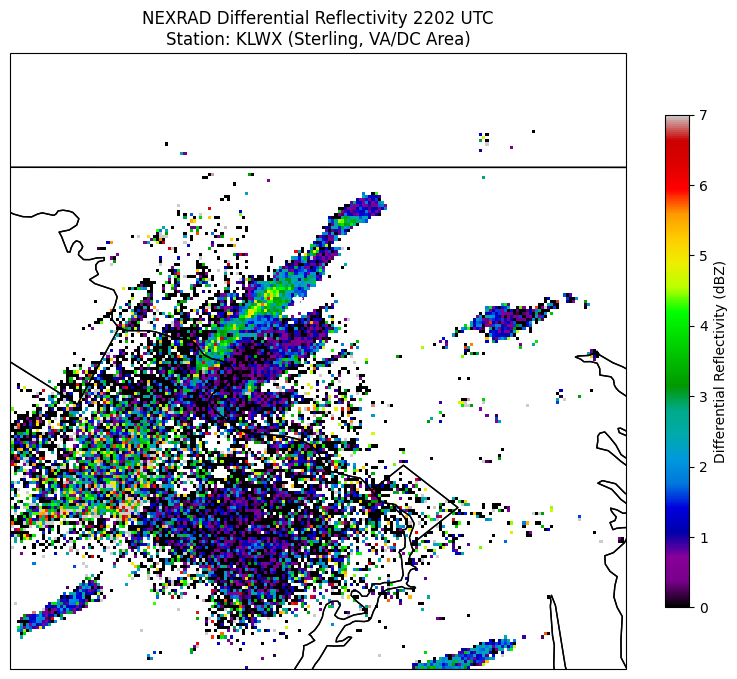

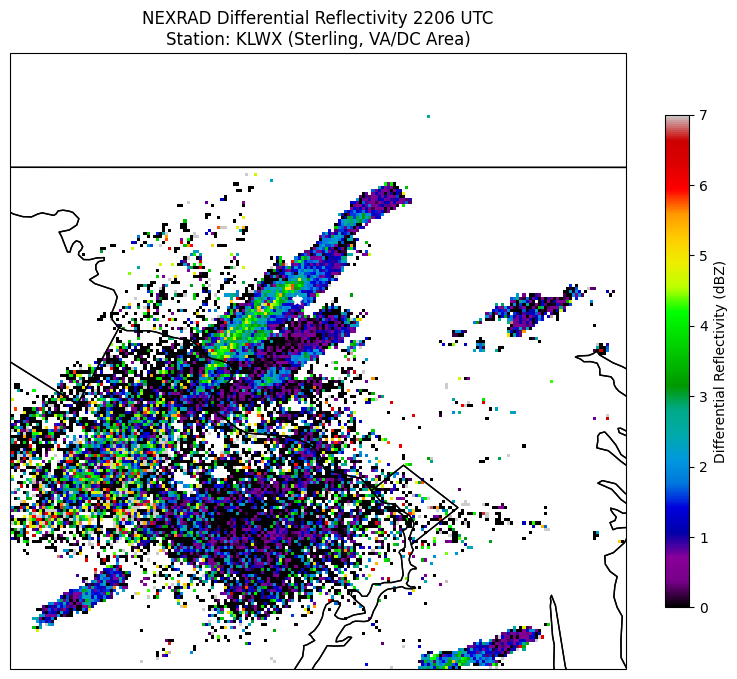

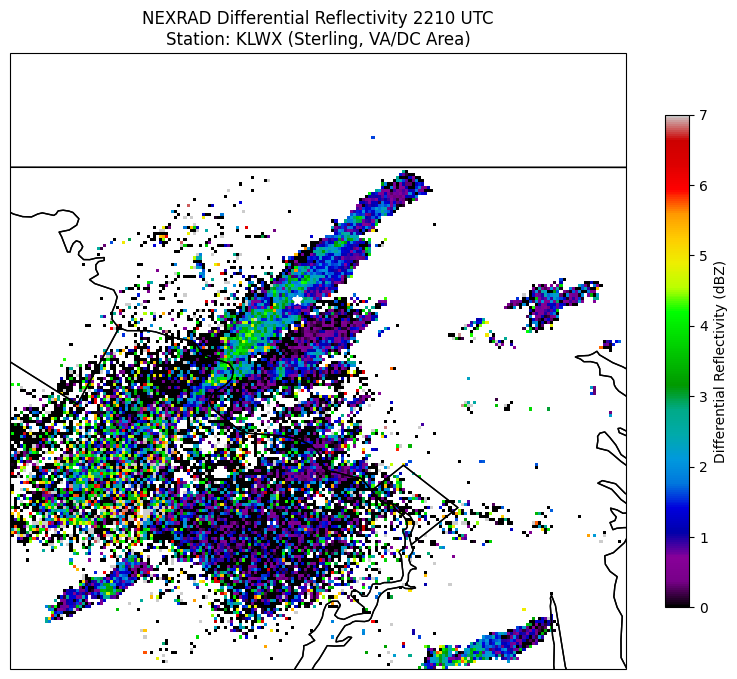

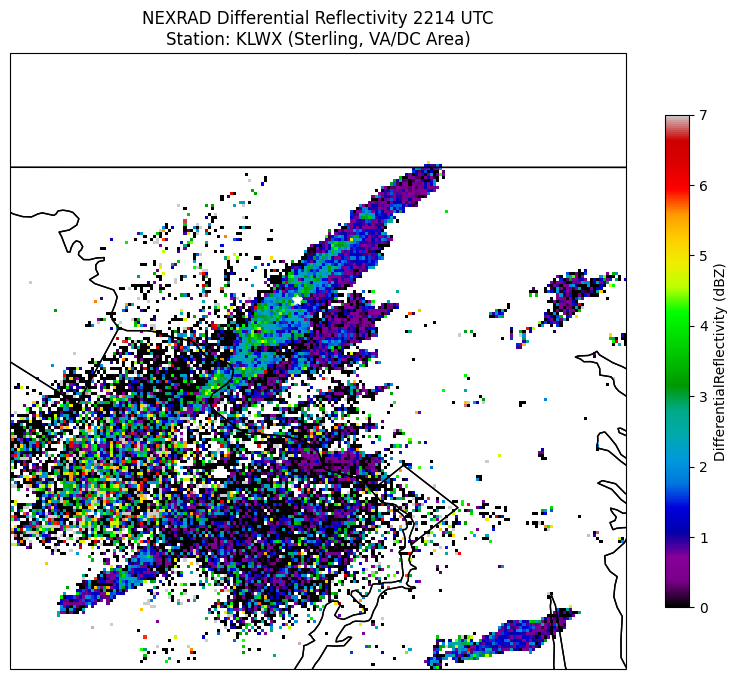

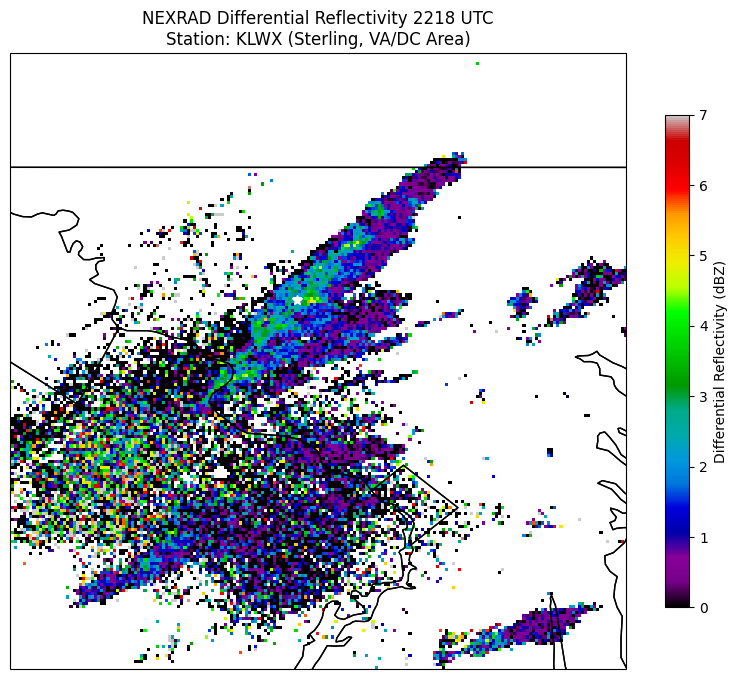

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset
import numpy as np

# Load the file
file_path = 'KLWX_V06_20251109_220203_ZDR.nc'

try:
    nc = Dataset(file_path, 'r')

    # Read the data variables
    # Based on the file snippet provided
    lats = nc.variables['lat'][:]
    lons = nc.variables['lon'][:]
    ref = nc.variables['DifferentialReflectivity'][:]

    # Close the file
    nc.close()

    # Pre-process the data
    # Squeeze to remove single dimensions (e.g., time) if they exist
    ref = np.squeeze(ref)

    # Mask missing or invalid data (often labeled as -999 or similar in radar data)
    # Reflectivity is typically masked below a certain threshold (like 0 or -30 dBZ)
    # Check for the '_FillValue' or 'missing_value' attribute in a real scenario
    # Here we mask values less than -30 dBZ which is typical for "no signal"
    ref_masked = np.ma.masked_less(ref, -30)

    # Set up the plot
    fig = plt.figure(figsize=(10, 8))

    # Define projection
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set extent to cover Central Maryland and surrounding areas
    # Approx Extent: West -78, East -76, South 38, North 40
    extent = [-78, -76.5, 38.5, 40]
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add Map Features
    ax.add_feature(cfeature.STATES, linewidth=1.0)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    # Adding counties can be helpful for radar
    #ax.add_feature(cfeature.COUNTIES, linewidth=0.3, linestyle=':')

    # Plot the Radar Data
    # 'nipy_spectral' is a popular colormap for radar reflectivity
    mesh = ax.pcolormesh(lons, lats, ref_masked,
                         transform=ccrs.PlateCarree(),
                         cmap='nipy_spectral',
                         vmin=0, vmax=7) # Standard dBZ range
    ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=ccrs.Geodetic())
    # Add Colorbar
    cbar = plt.colorbar(mesh, orientation='vertical', label='Differential Reflectivity (dBZ)', shrink=0.8)

    # Title
    plt.title('NEXRAD Differential Reflectivity 2202 UTC\nStation: KLWX (Sterling, VA/DC Area)')
    plt.savefig("KLWX_V06_20251109_2202_ZDR.png",dpi=250,bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

# Load the file
file_path = 'KLWX_V06_20251109_220626_ZDR.nc'

try:
    nc = Dataset(file_path, 'r')

    # Read the data variables
    # Based on the file snippet provided
    lats = nc.variables['lat'][:]
    lons = nc.variables['lon'][:]
    ref = nc.variables['DifferentialReflectivity'][:]

    # Close the file
    nc.close()

    # Pre-process the data
    # Squeeze to remove single dimensions (e.g., time) if they exist
    ref = np.squeeze(ref)

    # Mask missing or invalid data (often labeled as -999 or similar in radar data)
    # Reflectivity is typically masked below a certain threshold (like 0 or -30 dBZ)
    # Check for the '_FillValue' or 'missing_value' attribute in a real scenario
    # Here we mask values less than -30 dBZ which is typical for "no signal"
    ref_masked = np.ma.masked_less(ref, -30)

    # Set up the plot
    fig = plt.figure(figsize=(10, 8))

    # Define projection
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set extent to cover Central Maryland and surrounding areas
    # Approx Extent: West -78, East -76, South 38, North 40
    extent = [-78, -76.5, 38.5, 40]
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add Map Features
    ax.add_feature(cfeature.STATES, linewidth=1.0)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    # Adding counties can be helpful for radar
    #ax.add_feature(cfeature.COUNTIES, linewidth=0.3, linestyle=':')

    # Plot the Radar Data
    # 'nipy_spectral' is a popular colormap for radar reflectivity
    mesh = ax.pcolormesh(lons, lats, ref_masked,
                         transform=ccrs.PlateCarree(),
                         cmap='nipy_spectral',
                         vmin=0, vmax=7) # Standard dBZ range
    ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=ccrs.Geodetic())
    # Add Colorbar
    cbar = plt.colorbar(mesh, orientation='vertical', label='Differential Reflectivity (dBZ)', shrink=0.8)

    # Title
    plt.title('NEXRAD Differential Reflectivity 2206 UTC\nStation: KLWX (Sterling, VA/DC Area)')
    plt.savefig("KLWX_V06_20251109_2206_ZDR.png",dpi=250,bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

# Load the file
file_path = 'KLWX_V06_20251109_221017_ZDR.nc'

try:
    nc = Dataset(file_path, 'r')

    # Read the data variables
    # Based on the file snippet provided
    lats = nc.variables['lat'][:]
    lons = nc.variables['lon'][:]
    ref = nc.variables['DifferentialReflectivity'][:]

    # Close the file
    nc.close()

    # Pre-process the data
    # Squeeze to remove single dimensions (e.g., time) if they exist
    ref = np.squeeze(ref)

    # Mask missing or invalid data (often labeled as -999 or similar in radar data)
    # Reflectivity is typically masked below a certain threshold (like 0 or -30 dBZ)
    # Check for the '_FillValue' or 'missing_value' attribute in a real scenario
    # Here we mask values less than -30 dBZ which is typical for "no signal"
    ref_masked = np.ma.masked_less(ref, -30)

    # Set up the plot
    fig = plt.figure(figsize=(10, 8))

    # Define projection
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set extent to cover Central Maryland and surrounding areas
    # Approx Extent: West -78, East -76, South 38, North 40
    extent = [-78, -76.5, 38.5, 40]
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add Map Features
    ax.add_feature(cfeature.STATES, linewidth=1.0)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    # Adding counties can be helpful for radar
    #ax.add_feature(cfeature.COUNTIES, linewidth=0.3, linestyle=':')

    # Plot the Radar Data
    # 'nipy_spectral' is a popular colormap for radar reflectivity
    mesh = ax.pcolormesh(lons, lats, ref_masked,
                         transform=ccrs.PlateCarree(),
                         cmap='nipy_spectral',
                         vmin=0, vmax=7) # Standard dBZ range
    ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=ccrs.Geodetic())
    # Add Colorbar
    cbar = plt.colorbar(mesh, orientation='vertical', label='Differential Reflectivity (dBZ)', shrink=0.8)

    # Title
    plt.title('NEXRAD Differential Reflectivity 2210 UTC\nStation: KLWX (Sterling, VA/DC Area)')
    plt.savefig("KLWX_V06_20251109_2210_ZDR.png",dpi=250,bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

# Load the file
file_path = 'KLWX_V06_20251109_221408_ZDR.nc'

try:
    nc = Dataset(file_path, 'r')

    # Read the data variables
    # Based on the file snippet provided
    lats = nc.variables['lat'][:]
    lons = nc.variables['lon'][:]
    ref = nc.variables['DifferentialReflectivity'][:]

    # Close the file
    nc.close()

    # Pre-process the data
    # Squeeze to remove single dimensions (e.g., time) if they exist
    ref = np.squeeze(ref)

    # Mask missing or invalid data (often labeled as -999 or similar in radar data)
    # Reflectivity is typically masked below a certain threshold (like 0 or -30 dBZ)
    # Check for the '_FillValue' or 'missing_value' attribute in a real scenario
    # Here we mask values less than -30 dBZ which is typical for "no signal"
    ref_masked = np.ma.masked_less(ref, -30)

    # Set up the plot
    fig = plt.figure(figsize=(10, 8))

    # Define projection
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set extent to cover Central Maryland and surrounding areas
    # Approx Extent: West -78, East -76, South 38, North 40
    extent = [-78, -76.5, 38.5, 40]
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add Map Features
    ax.add_feature(cfeature.STATES, linewidth=1.0)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    # Adding counties can be helpful for radar
    #ax.add_feature(cfeature.COUNTIES, linewidth=0.3, linestyle=':')

    # Plot the Radar Data
    # 'nipy_spectral' is a popular colormap for radar reflectivity
    mesh = ax.pcolormesh(lons, lats, ref_masked,
                         transform=ccrs.PlateCarree(),
                         cmap='nipy_spectral',
                         vmin=0, vmax=7) # Standard dBZ range
    ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=ccrs.Geodetic())
    # Add Colorbar
    cbar = plt.colorbar(mesh, orientation='vertical', label='DifferentialReflectivity (dBZ)', shrink=0.8)

    # Title
    plt.title('NEXRAD Differential Reflectivity 2214 UTC\nStation: KLWX (Sterling, VA/DC Area)')
    plt.savefig("KLWX_V06_20251109_2214_ZDR.png",dpi=250,bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

# Load the file
file_path = 'KLWX_V06_20251109_221812_ZDR.nc'

try:
    nc = Dataset(file_path, 'r')

    # Read the data variables
    # Based on the file snippet provided
    lats = nc.variables['lat'][:]
    lons = nc.variables['lon'][:]
    ref = nc.variables['DifferentialReflectivity'][:]

    # Close the file
    nc.close()

    # Pre-process the data
    # Squeeze to remove single dimensions (e.g., time) if they exist
    ref = np.squeeze(ref)

    # Mask missing or invalid data (often labeled as -999 or similar in radar data)
    # Reflectivity is typically masked below a certain threshold (like 0 or -30 dBZ)
    # Check for the '_FillValue' or 'missing_value' attribute in a real scenario
    # Here we mask values less than -30 dBZ which is typical for "no signal"
    ref_masked = np.ma.masked_less(ref, -30)

    # Set up the plot
    fig = plt.figure(figsize=(10, 8))

    # Define projection
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set extent to cover Central Maryland and surrounding areas
    # Approx Extent: West -78, East -76, South 38, North 40
    extent = [-78, -76.5, 38.5, 40]
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add Map Features
    ax.add_feature(cfeature.STATES, linewidth=1.0)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    # Adding counties can be helpful for radar
    #ax.add_feature(cfeature.COUNTIES, linewidth=0.3, linestyle=':')

    # Plot the Radar Data
    # 'nipy_spectral' is a popular colormap for radar reflectivity
    mesh = ax.pcolormesh(lons, lats, ref_masked,
                         transform=ccrs.PlateCarree(),
                         cmap='nipy_spectral',
                         vmin=0, vmax=7) # Standard dBZ range
    ax.plot(-77.299990, 39.399529, '*w', markersize=7, transform=ccrs.Geodetic())
    # Add Colorbar
    cbar = plt.colorbar(mesh, orientation='vertical', label='Differential Reflectivity (dBZ)', shrink=0.8)

    # Title
    plt.title('NEXRAD Differential Reflectivity 2218 UTC\nStation: KLWX (Sterling, VA/DC Area)')
    plt.savefig("KLWX_V06_20251109_2218_ZDR.png",dpi=250,bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

In [14]:
import glob
from PIL import Image

def make_gif(frame_folder, output_filename, duration=100, loop=0):
    """
    Creates an animated GIF from images in a folder.

    :param frame_folder: Path to the folder containing image frames.
    :param output_filename: The name of the output GIF file.
    :param duration: Duration of each frame in milliseconds (default 100ms).
    :param loop: The number of times the GIF should loop (0 means infinite loop).
    """
    # Use glob to find all JPG files and sort them
    frames = [Image.open(image) for image in sorted(glob.glob(f"{frame_folder}/*.PNG"))]
    
    # Ensure images have the same dimensions for best results
    
    # The first frame is used to save the file and append the rest of the frames
    if frames:
        frame_one = frames[0]
        frame_one.save(
            output_filename, 
            format="GIF", 
            append_images=frames[1:], 
            save_all=True, 
            duration=duration, 
            loop=loop
        )
        print(f"GIF saved as {output_filename}")
    else:
        print("No images found in the specified folder.")

# Example usage (replace '/path/to/images' with your actual folder path)
if __name__ == "__main__":
    make_gif("./ZDR_LWX", "ZDR_LWX_1109.gif", duration=1000, loop=0)

GIF saved as ZDR_LWX_1109.gif


C:\Users\ken.pryor\AppData\Local\Temp\1\ipykernel_17292\1078697759.py:73: RuntimeWarning: invalid value encountered in sqrt
  W_ms = np.sqrt(discriminant)


W_kts shape: (689, 920)
Max Index: (np.int64(403), np.int64(478))
Max Value: 41.25302160747422
Max lat: 39.372965527653264
Max lon: -77.34818915558603


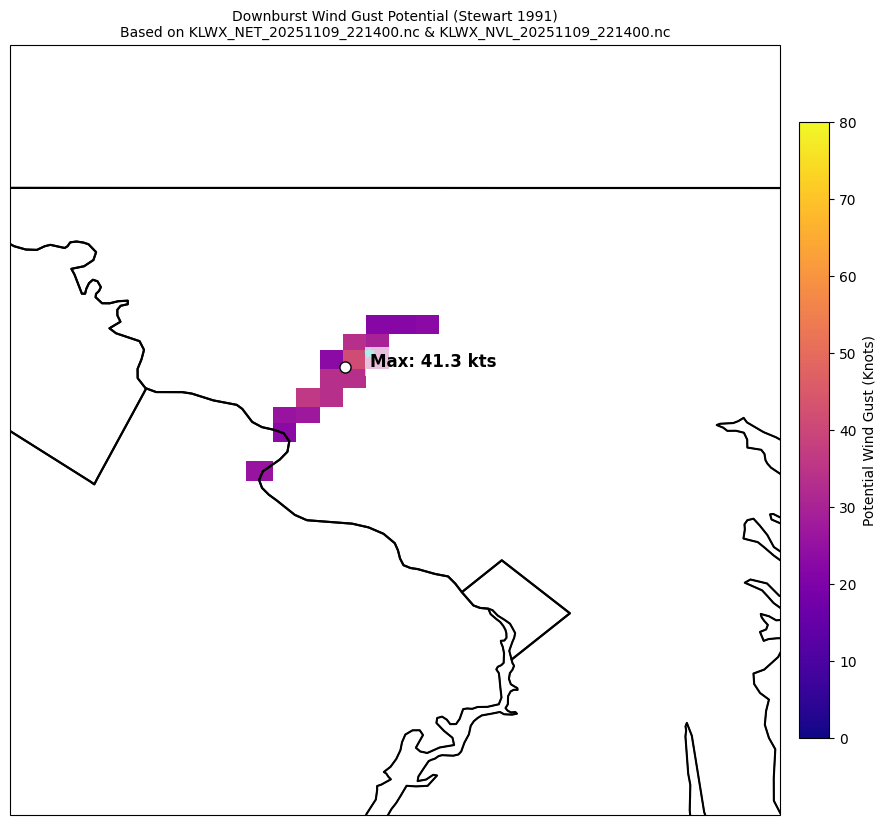

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset
import numpy as np

# --------------------------------------------------------------------------------
# 1. Configuration & File Loading
# --------------------------------------------------------------------------------
# Define file paths based on the uploaded files
net_file = 'KLWX_NET_20251109_221400.nc'  # Echo Tops
nvl_file = 'KLWX_NVL_20251109_221400.nc'  # VIL

try:
    # Load Echo Tops (NET)
    nc_net = Dataset(net_file, 'r')
    lats = nc_net.variables['lat'][:]
    lons = nc_net.variables['lon'][:]
    # Variable name in Level III NET files is typically 'et' or 'value'
    # Based on snippets, 'et' is likely for NET
    et_data_kft = nc_net.variables['et'][:]
    nc_net.close()

    # Load VIL (NVL)
    nc_nvl = Dataset(nvl_file, 'r')
    # Variable name in Level III NVL files is typically 'vil' or 'value'
    # Based on snippets, 'vil' is likely for NVL
    vil_data = nc_nvl.variables['vil'][:]
    nc_nvl.close()

    # --------------------------------------------------------------------------------
    # 2. Data Pre-processing
    # --------------------------------------------------------------------------------
    # Squeeze dimensions to remove time/single dims
    et_data_kft = np.squeeze(et_data_kft)
    vil_data = np.squeeze(vil_data)

    # Mask missing/invalid data (Values < 0 are typically background/missing)
    et_data_kft = np.ma.masked_less(et_data_kft, 0)
    vil_data = np.ma.masked_less(vil_data, 0)

    # Convert Echo Tops (H) to Meters
    # 1 kft = 304.8 meters
    H = et_data_kft * 304.8

    # --------------------------------------------------------------------------------
    # 3. Calculate Downburst Potential (W)
    # --------------------------------------------------------------------------------
    # Formula: W = sqrt( (20.628571 * Rc * H) - (0.000003125 * H^2) )
    # Where Rc = VIL / H

    # Calculate Rc (VIL Density)
    # Note: VIL is kg/m^2. H is meters. Resulting Rc is kg/m^3.
    # This matches the unit magnitude required for the coefficient ~20.6 (approx 2*g)
    with np.errstate(divide='ignore', invalid='ignore'):
        Rc = vil_data / H

    # Term 1: Water Loading Potential
    term1 = 20.628571 * Rc * H
    # Note: Since Rc = VIL/H, this simplifies mathematically to 20.628571 * VIL
    # However, we calculate it explicitly as requested to follow the physics derivation.

    # Term 2: Stability/Entrainment dampening
    term2 = 0.000003125 * (H**2)

    # Calculate Discriminant
    discriminant = term1 - term2

    # Mask physically impossible values (negative discriminant)
    discriminant = np.ma.masked_less(discriminant, 0)

    # Calculate W (m/s)
    W_ms = np.sqrt(discriminant)

    # Convert to Knots (1 m/s = 1.94384 knots)
    W_kts = W_ms * 1.94384
    print("W_kts shape:", W_kts.shape)

    # --------------------------------------------------------------------------------
    # 4. Visualization
    # --------------------------------------------------------------------------------
    fig = plt.figure(figsize=(12, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Set Map Extent (Zoom to data bounds)
    #ax.set_extent([np.min(lons), np.max(lons), np.min(lats), np.max(lats)], crs=ccrs.PlateCarree())
    extent = [-78, -76.5, 38.5, 40]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    # Add Map Features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, linewidth=1.5, edgecolor='black')
    #ax.add_feature(cfeature.COUNTIES, linewidth=0.5, linestyle=':', alpha=0.6)

    # Plot the Wind Gust Potential
    # We use a colormap that highlights severe winds (Yellow/Red/Magenta)
    # Mask values below 20 knots to focus on active storms
    W_plot = np.ma.masked_less(W_kts, 20)

    mesh = ax.pcolormesh(lons, lats, W_plot,
                         transform=ccrs.PlateCarree(),
                         cmap='plasma',
                         vmin=0, vmax=80)

    ax.plot(-77.299990, 39.399529, '*c', markersize=7, transform=ccrs.Geodetic())
    # Add Colorbar
    cbar = plt.colorbar(mesh, orientation='vertical', shrink=0.8, pad=0.02)
    cbar.set_label('Potential Wind Gust (Knots)')

    # Add Titles
    plt.title(f"Downburst Wind Gust Potential (Stewart 1991)\nBased on {net_file} & {nvl_file}", fontsize=10)

    # Add Marker for Max Value
    if np.any(W_kts > 0):
        max_idx = np.unravel_index(np.argmax(W_kts), W_kts.shape)
        print("Max Index:", max_idx)
        max_val = W_kts[403,478]
        print("Max Value:", max_val)
        max_lat = lats[403]
        print("Max lat:", max_lat)
        max_lon = lons[478]
        print("Max lon:", max_lon)

        # Plot a marker at the max location
        ax.plot(max_lon, max_lat, 'wo', markeredgecolor='black', markersize=8, transform=ccrs.PlateCarree())
        plt.text(max_lon + 0.05, max_lat, f"Max: {max_val:.1f} kts",
                 transform=ccrs.PlateCarree(), color='black', fontsize=12, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    plt.savefig("KLWX_WGP_2214.png",dpi=250,bbox_inches='tight')
    plt.show()

except FileNotFoundError as e:
    print(f"File not found: {e}")
except KeyError as e:
    print(f"Key Error (Check Variable Names): {e}")
    print("Available variables in NET:", Dataset(net_file).variables.keys())
    print("Available variables in NVL:", Dataset(nvl_file).variables.keys())
except Exception as e:
    print(f"An unexpected error occurred: {e}")